In [1]:
math = [0.04,0.11,0.2,0.12,0.17,0.28,0.38,7.3,72.76,105.46]
bound = [0.03,0.04,0.05,0.05,0.06,0.07,0.14,0.40,0.83,1.51,2.94,6.04]
avg = []

for i in range(len(math)):
    avg.append((math[i] / bound[i]))

print(avg)

average_avg = sum(avg) / len(avg)
print(average_avg)

[1.3333333333333335, 2.75, 4.0, 2.4, 2.8333333333333335, 4.0, 2.714285714285714, 18.25, 87.66265060240966, 69.841059602649]
19.578466258601104


In [2]:
list = [18.25, 87.66265060240966, 69.841059602649]

average_list = sum(list) / len(list)
print(average_list)

58.58457006835289


In [44]:
bound = [0.03,0.04,0.05,0.05,0.06,0.07,0.14,0.40,0.83,1.51,2.94,6.04]

greedy =[0.02,0.05,0.02,0.03,0.03,0.04,0.07,0.08,0.13,0.25,0.44,0.49]

build = [0,0,0.06,14.04,0.02,0,1.31,19.34,1.89,3.01,10.50,20.58]
total = []
for i in range(len(bound)):

    total.append(bound[i] + greedy[i]/60 + build[i]/60)


for i in range(len(total)):
    print (f"{total[i]:.2f} min")

0.03 min
0.04 min
0.05 min
0.28 min
0.06 min
0.07 min
0.16 min
0.72 min
0.86 min
1.56 min
3.12 min
6.39 min


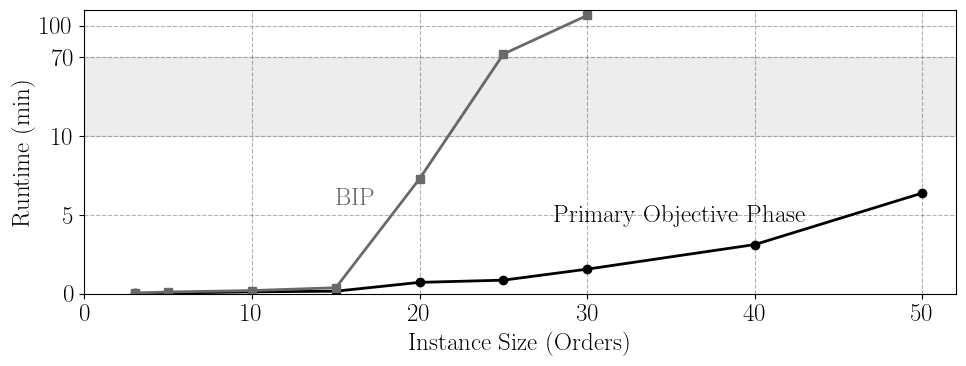

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Stil: wissenschaftlich, LaTeX
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# ----------------------------
# Y-Transformationsfunktion mit 2 Achsensprüngen:
# 10–70 → 10–15, 70–110 → 15–18
# ----------------------------
def y_transform(y_vals):
    transformed = []
    for val in y_vals:
        if val <= 10:
            transformed.append(val)
        elif val <= 70:
            transformed.append(10 + (val - 10) * (5 / 60))  # 10–70 auf 10–15
        else:
            transformed.append(15 + (val - 70) * (3 / 40))  # 70–110 auf 15–18
    return transformed

# ----------------------------
# Daten
# ----------------------------
instances = [3, 5, 10, 15, 20, 25, 30, 40, 50]
lp_runtime = [0.03, 0.04, 0.12, 0.16, 0.72, 0.86, 1.56, 3.12, 6.39]
comp_runtime = [0.04, 0.11, 0.20, 0.38, 7.30, 72.76, 105.46, np.nan, np.nan]


# Transformierte Y-Werte
lp_trans = y_transform(lp_runtime)
comp_trans = y_transform(comp_runtime[:7])

# ----------------------------
# Plot erstellen
# ----------------------------
plt.figure(figsize=(10, 4))
plt.grid(True, which="both", linestyle="--", color="black", alpha=0.3)

# Achsenbeschriftung
plt.xlabel("Instance Size (Orders)")
plt.ylabel("Runtime (min)")
plt.xlim(0, 52)
plt.ylim(0, 18)  # passt zu transformiertem Bereich

# Angepasste Y-Achsenticks & Labels
plt.yticks(
    [0, 5, 10, 15,  17],
    ["0", "5", "10", "70", "100"]
)

# Achsensprünge markieren
plt.axhspan(10, 15, color="lightgrey", alpha=0.4, label="Break: 10–70")
#plt.axhspan(15, 18, color="lightgrey", alpha=0.3, label="Break: 70–110")

# ----------------------------
# LP Runtime Linie
# ----------------------------
plt.plot(instances, lp_trans, color="black", marker="o", linestyle="-", linewidth=2,
         markersize=6, label="LP Runtime")

# Comparison Runtime Linie (nur bis 30)
plt.plot(instances[:7], comp_trans, color="dimgray", marker="s", linestyle="-", linewidth=2,
         markersize=6, label="Comparison")

# Gestrichelte Verbindung zwischen Break-Punkten (7.30 → 72.76)
x_start = instances[4]  # bei 7.30
x_end = instances[5]    # bei 72.76
y_start = comp_trans[4]
y_end = comp_trans[5]
plt.plot([x_start, x_end], [y_start, y_end],
         linestyle="--", linewidth=1.5, color="dimgray")

# ----------------------------
# Beschriftungen im Plot
# ----------------------------
plt.text(28, lp_trans[6]+3.0, "Primary Objective Phase", fontsize=18, color="black")
plt.text(15, comp_trans[4]-1.7, "BIP", fontsize=18, color="dimgray")

# ----------------------------
# Speichern & Anzeigen
# ----------------------------
plt.tight_layout()
plt.savefig("runtime_comparison_bip_primary_phase.pdf", bbox_inches="tight")
plt.show()

In [2]:
import pandas as pd

# Dominanzprüfung
def dominates(sol_a, sol_b):
    """True, wenn sol_a sol_b dominiert (bei Minimierungszielen)"""
    better_in_all = True
    better_in_at_least_one = False

    for key in sol_a:
        a, b = sol_a[key], sol_b[key]
        if a > b:
            better_in_all = False
        elif a < b:
            better_in_at_least_one = True

    return better_in_all and better_in_at_least_one

# --------------------------
# Instanzen definieren
# --------------------------
instances = [
    "a3_o80_m10_an10_ar9_reduced",
    "a5_o96_m10_an10_ar10_reduced",
    "a10_o107_m5_an57_ar12",
    "a10_o114_m6_an57_ar11",
    "a10_o128_m6_an51_ar13",
    "a10_o144_m6_an53_ar12",
    "a15_o170_m9_an80_ar18",
    "a20_o236_m12_an106_ar24",
    "a25_o306_m13_an127_ar31",
    "a30_o355_m18_an148_ar42"
]

# --------------------------
# Externe Lösungen laden
# --------------------------
csv_path = "../Solution_math_model/BIP_experiment_3_full_solution.csv"
df = pd.read_csv(csv_path)

columns_of_interest = {
    "Driver Violation": "Driver Violation",
    "Commute Distance": "Commute Distance",
    "Transport Machines": "Transport Distance",
    "Transport Attachments": "Attachment Distance",
    "Machines": "Machine Count",
    "Workers": "Worker Count",
    "Attachments": "Attachment Count"
}

external_solution_s = {
    row["Instance"]: {
        new_key: row[original_col]
        for new_key, original_col in columns_of_interest.items()
    }
    for _, row in df.iterrows()
}

# --------------------------
# Übersichtstabelle vorbereiten
# --------------------------
results = []
results_percentage = []

# --------------------------
# Analyse für jede Instanz
# --------------------------
for instance in instances:
    print(f"\n🔍 Analysiere Pareto-Front für Instanz: {instance}")
    
    # Lade Pareto-Front der Instanz
    df_pareto = pd.read_csv(f"{instance}/TPSA/ParetoFront.csv")

    # Externe Lösung holen
    external_solution = external_solution_s[instance]

    # Relevante Spalten extrahieren
    cols = list(external_solution.keys())
    pareto_solutions = df_pareto[cols]

    # Zähler
    dominated_by_count = 0
    dominates_count = 0
    non_dominated_count = 0

    for _, row in pareto_solutions.iterrows():
        sol = row.to_dict()
        if dominates(sol, external_solution):
            dominated_by_count += 1
        elif dominates(external_solution, sol):
            dominates_count += 1
        else:
            non_dominated_count += 1

    # Urteil fällen
    if dominated_by_count > 0:
        verdict = "dominated"
    elif dominates_count > 0:
        verdict = "dominates"
    else:
        verdict = "pareto-neutral"

    # Ergebnis zwischenspeichern
    results.append({
        "Instance": instance,
        "#Pareto Solutions": len(pareto_solutions),
        "#Dominate BIP": dominated_by_count,
        "#Dominated by BIP": dominates_count,
        "#Pareto-neutral": non_dominated_count,
        "Verdict": verdict
    })

    # Ergebnis ausgeben
    print(f"  ➤ Anzahl Lösungen in Pareto-Approximation: {len(pareto_solutions)}")
    print(f"  ➤ ... die externe Lösung dominieren: {dominated_by_count}")
    print(f"  ➤ ... von der externen Lösung dominiert werden: {dominates_count}")
    print(f"  ➤ ... pareto-neutral zur externen Lösung sind: {non_dominated_count}")
    print(f"  ⇒ Urteil: {verdict}")

    total = len(pareto_solutions)
    results_percentage.append({
        "Instance": instance,
        "#Pareto Solutions": total,
        "% Dominate BIP": round(dominated_by_count / total * 100, 1),
        "% Dominated by BIP": round(dominates_count / total * 100, 1),
        "% Pareto-neutral": round(non_dominated_count / total * 100, 1),
        "Verdict": verdict
    })

# --------------------------
# Tabelle erzeugen und anzeigen
# --------------------------
summary_df = pd.DataFrame(results)
summary_df_percentage = pd.DataFrame(results_percentage)

print("\n📊 Zusammenfassung der Dominanzanalyse:")
display(summary_df)  # In Jupyter Notebook
display(summary_df_percentage)  # In Jupyter Notebook
# print(summary_df)   # In .py-Skripten verwenden


🔍 Analysiere Pareto-Front für Instanz: a3_o80_m10_an10_ar9_reduced
  ➤ Anzahl Lösungen in Pareto-Approximation: 108
  ➤ ... die externe Lösung dominieren: 0
  ➤ ... von der externen Lösung dominiert werden: 51
  ➤ ... pareto-neutral zur externen Lösung sind: 57
  ⇒ Urteil: dominates

🔍 Analysiere Pareto-Front für Instanz: a5_o96_m10_an10_ar10_reduced
  ➤ Anzahl Lösungen in Pareto-Approximation: 127
  ➤ ... die externe Lösung dominieren: 0
  ➤ ... von der externen Lösung dominiert werden: 0
  ➤ ... pareto-neutral zur externen Lösung sind: 127
  ⇒ Urteil: pareto-neutral

🔍 Analysiere Pareto-Front für Instanz: a10_o107_m5_an57_ar12
  ➤ Anzahl Lösungen in Pareto-Approximation: 248
  ➤ ... die externe Lösung dominieren: 0
  ➤ ... von der externen Lösung dominiert werden: 8
  ➤ ... pareto-neutral zur externen Lösung sind: 240
  ⇒ Urteil: dominates

🔍 Analysiere Pareto-Front für Instanz: a10_o114_m6_an57_ar11
  ➤ Anzahl Lösungen in Pareto-Approximation: 295
  ➤ ... die externe Lösung dominie

,Instance,#Pareto Solutions,#Dominate BIP,#Dominated by BIP,#Pareto-neutral,Verdict
0,a3_o80_m10_an10_ar9_reduced,108,0,51,57,dominates
1,a5_o96_m10_an10_ar10_reduced,127,0,0,127,pareto-neutral
2,a10_o107_m5_an57_ar12,248,0,8,240,dominates
3,a10_o114_m6_an57_ar11,295,0,11,284,dominates
4,a10_o128_m6_an51_ar13,696,0,143,553,dominates
5,a10_o144_m6_an53_ar12,311,0,9,302,dominates
6,a15_o170_m9_an80_ar18,1149,0,0,1149,pareto-neutral
7,a20_o236_m12_an106_ar24,672,0,0,672,pareto-neutral
8,a25_o306_m13_an127_ar31,962,47,0,915,dominated
9,a30_o355_m18_an148_ar42,1260,0,0,1260,pareto-neutral


,Instance,#Pareto Solutions,% Dominate BIP,% Dominated by BIP,% Pareto-neutral,Verdict
0,a3_o80_m10_an10_ar9_reduced,108,0.0,47.2,52.8,dominates
1,a5_o96_m10_an10_ar10_reduced,127,0.0,0.0,100.0,pareto-neutral
2,a10_o107_m5_an57_ar12,248,0.0,3.2,96.8,dominates
3,a10_o114_m6_an57_ar11,295,0.0,3.7,96.3,dominates
4,a10_o128_m6_an51_ar13,696,0.0,20.5,79.5,dominates
5,a10_o144_m6_an53_ar12,311,0.0,2.9,97.1,dominates
6,a15_o170_m9_an80_ar18,1149,0.0,0.0,100.0,pareto-neutral
7,a20_o236_m12_an106_ar24,672,0.0,0.0,100.0,pareto-neutral
8,a25_o306_m13_an127_ar31,962,4.9,0.0,95.1,dominated
9,a30_o355_m18_an148_ar42,1260,0.0,0.0,100.0,pareto-neutral
